# Characterizing parameter uncertainty with MLE asymptotics

## Exposition

## MLE Asymptotics
Recall that an MLE estimator converges in distribution to a normal distribution:

$$ \sqrt{n}(\hat{\theta}_{mle} - \theta) \to N(0, I^{-1}(\theta))$$

where $I(\theta)$ is the Fisher information matrix. Assuming the asymptotic approximation holds for $n = 6$, we can thus characterize parameter uncertainty by sampling from the distribution 

$$N(\hat{\theta}_{mle}, \hat{V})$$

where $\hat{V} = I^{-1}(\hat{\theta}_{mle})$.

## Reparametrization

Our ultimate parameter of interest is $\theta = (p_0, \xi, \sigma)$ with parameter bounds:

$$ 0 \leq p_0 \leq 1$$
$$ \xi > -1$$
$$ \sigma > 0$$

To obtain estimated parameter distributions respecting these boundaries, we conduct MLE using the following reparametrizations:

$$p_0 = \frac{1}{1 + e^{\phi_1}}$$
$$\xi = -1 + \ln(1 + e^{\phi_2})$$
$$\sigma = \ln({1 + e^{\phi_3}})$$

This gives us $\hat{\phi} = (\hat{\phi_1}, \hat{\phi_2}, \hat{\phi_3})$, which live in unconstrained real number domains. Assuming MLE asymptotics have kicked in these are approximately distributed $N(\hat{\phi}, \hat{V_{\phi}})$.

To obtain parameter distributions over $\theta$, we simply sample from $N(\hat{\phi}, \hat{V_{\phi}})$ and transform back to the constrained space using the inverses of the reparametrization functions.

### Execution and results

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import genpareto

In [30]:
rng = np.random.default_rng()
THRESHOLD = 0.01
MAX_INTENSITY = 57

In [31]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")

intensity_data = final_allrisk_ds['intensity']
duration_data = final_allrisk_ds['duration']

intensity_annual = final_allrisk_ds.set_index('year_start')['intensity'].copy()

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_annual = intensity_annual.reindex(all_years, fill_value=0)

In [32]:
# ---------- transforms ----------
def transform_unconstrain(p, xi, sigma):
    """θ → ϕ"""
    phi1 = np.log1p(-p) - np.log(p)              # log-odds
    phi2 = np.log(np.exp(xi + 1.0) - 1.0)        # softplus-1 inverse
    phi3 = np.log(np.exp(sigma) - 1.0)           # softplus inverse
    return np.array([phi1, phi2, phi3])

def transform_constrain(phi):
    """ϕ → θ"""
    phi1, phi2, phi3 = phi
    p     = 1.0 / (1.0 + np.exp(phi1))           # sigmoid
    xi    = np.log1p(np.exp(phi2)) - 1.0         # softplus-1
    sigma = np.log1p(np.exp(phi3))               # softplus
    return np.array([p, xi, sigma])

In [33]:
def neg_loglik_theta(theta, x, thresh):
    p, xi, sigma = theta

    excess_idx = x > thresh
    excesses = x[x > thresh]
    
    loglik_below_thresh = np.sum(~excess_idx * np.log1p(-p))
    loglik_above_thresh = np.sum(np.log(p) + genpareto.logpdf(excesses, c=xi, loc=thresh, scale=sigma))

    return -(loglik_below_thresh + loglik_above_thresh)

In [34]:
def neg_loglik_phi(phi, data, thresh):
    theta = transform_constrain(phi)
    return neg_loglik_theta(theta, data, thresh)         # call the original

In [35]:
theta_start   = np.array([0.2, 0.1, 1.5])
phi_start     = transform_unconstrain(*theta_start)

res = minimize(
        fun   = neg_loglik_phi,
        x0    = phi_start,
        args  = (intensity_annual, THRESHOLD),
        method= "BFGS"          # switch to L-BFGS-B if you have many params
      )

phi_hat   = res.x
theta_hat = transform_constrain(phi_hat)

In [36]:
phi_hat, theta_hat

(array([2.97892481, 1.86578535, 2.18545015]),
 array([0.04838711, 1.00969053, 2.29199437]))

In [37]:
if hasattr(res.hess_inv, "todense"):
    V_phi = res.hess_inv.todense()
else:
    V_phi = res.hess_inv
V_phi = np.asarray(V_phi, dtype=float)          # 3×3
V_phi

array([[ 0.16287549, -0.0059328 ,  0.02581147],
       [-0.0059328 ,  0.65261095, -0.42315345],
       [ 0.02581147, -0.42315345,  2.91839086]])

In [38]:
n_samples = 100_000
phi_draws = rng.multivariate_normal(phi_hat, V_phi, size=n_samples)
theta_draws = np.stack([transform_constrain(z) for z in phi_draws])
p_draws, xi_draws, sigma_draws = np.hsplit(theta_draws, 3)

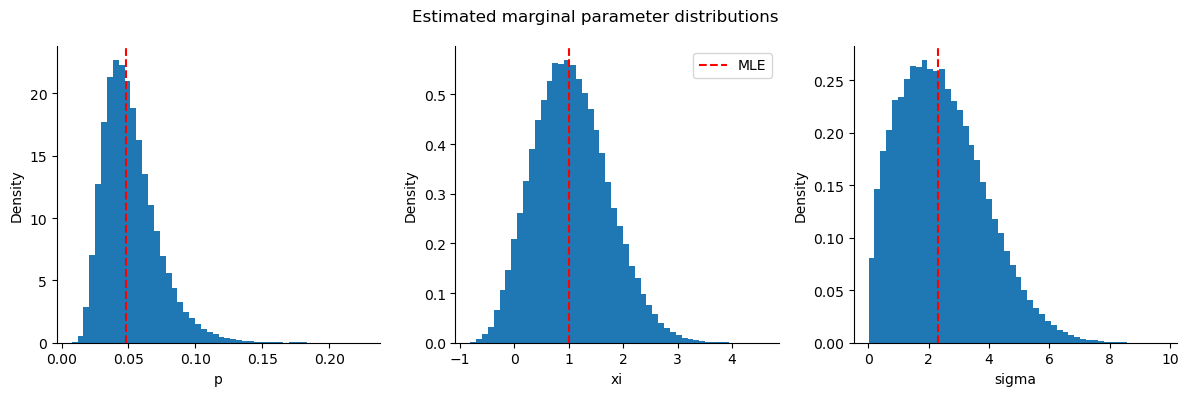

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
param_names = ['p', 'xi', 'sigma']

for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(theta_draws[:, i], bins=50, density=True)
    ax.axvline(theta_hat[i], color='red', linestyle='--', label='MLE')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 1:
    	ax.legend()

plt.suptitle("Estimated marginal parameter distributions")
plt.tight_layout()
plt.show()

In [ ]:
# Create intensity thresholds
intensity_thresholds = np.logspace(np.log10(THRESHOLD), np.log10(MAX_INTENSITY), 1000)
intensity_thresholds_mat = np.tile(intensity_thresholds, (n_samples, 1))

# Calculate survival functions for each sample
intensity_survivals = (
    p_draws * genpareto.sf(
        intensity_thresholds_mat,
        xi_draws,
        loc=THRESHOLD,
        scale=sigma_draws
    )
)

# Calculate percentiles for credible intervals
intensity_percentiles = np.percentile(intensity_survivals, [5, 50, 95], axis=0)

# Plot exceedance probability curve
plt.figure(figsize=(10, 6))

# Plot median and credible intervals
plt.plot(intensity_thresholds, intensity_percentiles[1], 'b-', linewidth=2, label='Median')
plt.plot(intensity_thresholds, intensity_percentiles[0], 'b:', alpha=0.5, label='90% confidence interval')
plt.plot(intensity_thresholds, intensity_percentiles[2], 'b:', alpha=0.5)

plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.xlabel('Intensity threshold')
plt.ylabel('Exceedance probability')
plt.title('Pandemic intensity exceedance probability')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()